# 🧠 Amazon Sentiment Analysis — V2B
## GloVe Pre-trained Embeddings + LSTM

**What this notebook does:**
- Loads Stanford's GloVe vectors (trained on 6 BILLION words)
- Maps YOUR Amazon review words to those GloVe vectors
- Trains LSTM for sentiment classification

**Why GloVe is better than Word2Vec for our project:**
```
Word2Vec (V2A) trained on 1,053 reviews  → limited knowledge
GloVe (V2B)   trained on 6,000,000,000 words → rich knowledge
```

**Before running this notebook:**
```
1. Go to: https://nlp.stanford.edu/projects/glove/
2. Download: glove.6B.zip (822 MB)
3. Extract and copy glove.6B.100d.txt to Example my project folder :
   D:\AMAZON_REVIEW_SENTIMENT\glove\glove.6B.100d.txt
```

**Pipeline:**
```
Raw Text → clean_text() → Tokenizer → GloVe Embedding (frozen) → LSTM → Positive/Negative
```

In [99]:
##Required libraries

## For data Handling
import pandas as pd
import numpy as np

## For visualization
import matplotlib.pyplot as plt
import seaborn as sns

## To remove words (clean text)
import re
import nltk

import warnings
warnings.filterwarnings('ignore')

##Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

**Declaring paths and variables

In [100]:
import os
os.chdir(r'D:\AMAZON_REVIEW_SENTIMENT')

DATA_PATH      = '/AMAZON_REVIEW_SENTIMENT/data/raw/amazon_review_dataset.csv'
GLOVE_PATH    = 'D:\AMAZON_REVIEW_SENTIMENT\glove\glove.6B.100d.txt'   # must exist!
#
REVIEW_COL     = 'reviews.text'      # column name for review text
RATING_COL  = 'reviews.rating'   # column name for label

# ─ GloVe + Embedding Settings ─
EMBEDDING_DIM = 100     # must match glove file (100d = 100)
MAX_WORDS     = 10000   # vocabulary size
MAX_LEN       = 100     # max words per review

# ─LSTM Settings ─
LSTM_UNITS  = 64
EPOCHS      = 15
BATCH_SIZE  = 16

# ══════════════════════════════════════════════════════════

# Verify GloVe file exists
if os.path.exists(GLOVE_PATH):
    size_mb = os.path.getsize(GLOVE_PATH) / (1024*1024)
    print(f"✅ GloVe file found: {GLOVE_PATH} ({size_mb:.0f} MB)")
else:
    print(f"❌ GloVe file NOT found at: {GLOVE_PATH}")
    print("   Download from: https://nlp.stanford.edu/projects/glove/")
    print("   File needed: glove.6B.100d.txt")
    print("   Place it in: D:\\AMAZON_REVIEW_SENTIMENT\\glove\\")

print(f"\n   Working directory: {os.getcwd()}")
print(f"   Embedding: {EMBEDDING_DIM}d GloVe, max_words={MAX_WORDS}")
print(f"   LSTM: max_len={MAX_LEN}, units={LSTM_UNITS}")

✅ GloVe file found: D:\AMAZON_REVIEW_SENTIMENT\glove\glove.6B.100d.txt (331 MB)

   Working directory: D:\AMAZON_REVIEW_SENTIMENT
   Embedding: 100d GloVe, max_words=10000
   LSTM: max_len=100, units=64


In [101]:
#Reading the raw data
df = pd.read_csv(DATA_PATH)
df.head(3)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams


In [102]:
print("Columns : ",df.columns.tolist())

Columns :  ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']


In [103]:
df.shape

(1597, 27)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

* data type is ok for only needed columns which is reviews.text and reviews.rating

In [105]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc
count,8.980000e+02,900.000000,1177.000000,0.0,0.0,0.0,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,NaN,NaN,NaN,8.443135e+11
std,3.416444e+09,197.150238,1.021445,NaN,NaN,NaN,3.416444e+09
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,NaN,NaN,NaN,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,NaN,NaN,NaN,8.487190e+11
max,8.487190e+11,997.000000,5.000000,NaN,NaN,NaN,8.487190e+11


In [106]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [107]:
## Checking missing value
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64

In [108]:
##dropping missing review rating
df = df.dropna(subset=[RATING_COL])
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   508
dateAdded                  0
dateUpdated                0
dimension                620
ean                      484
keys                       0
manufacturer             451
manufacturerNumber       479
name                       0
prices                     0
reviews.date             217
reviews.doRecommend      638
reviews.numHelpful       277
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
reviews.userCity        1177
reviews.userProvince    1177
reviews.username           0
sizes                   1177
upc                      484
weight                   525
dtype: int64

In [109]:
df.shape

(1177, 27)

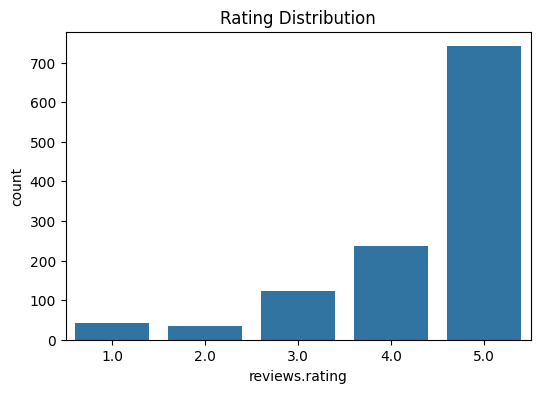

In [110]:
## Checking rating value by diagram
plt.figure(figsize=(6,4))
sns.countplot(x=RATING_COL, data=df)
plt.title("Rating Distribution")
plt.show()

In [111]:
# Check rating values 
print("Rating distribution:")
print(df[RATING_COL].value_counts().sort_index())
print()

Rating distribution:
reviews.rating
1.0     42
2.0     34
3.0    124
4.0    236
5.0    741
Name: count, dtype: int64



In [112]:
df = df[[REVIEW_COL, RATING_COL]]


In [113]:
df

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0
...,...,...
1592,This is not the same remote that I got for my ...,3.0
1593,I have had to change the batteries in this rem...,1.0
1594,"Remote did not activate, nor did it connect to...",1.0
1595,It does the job but is super over priced. I fe...,3.0


In [114]:
df.shape

(1177, 2)

In [115]:
##defining a function for converting in sentiment label
def label_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return None  # Neutral (we drop these)

df["sentiment"] = df[RATING_COL].apply(label_sentiment)

In [116]:
##Remove neutral review
df = df.dropna(subset=["sentiment"])
df["sentiment"].value_counts()

sentiment
1.0    977
0.0     76
Name: count, dtype: int64

## 📊 Data Imbalance — Observation (Carried from v2a)

---

### Dataset Distribution

| Class | Count | Percentage |
|-------|-------|------------|
| ✅ Positive | 977 | 92.8% |
| ❌ Negative | 76  | 7.2%  |

> Same imbalance from v2a (Word2Vec + LSTM) — no resampling done.

---

### ✔ What We Learned from v2a

- `class_weight` worked effectively inside `model.fit()`
- LSTM detected negatives without any data augmentation
- SMOTE was **NOT** needed for sequence-based deep learning

---

### 🔁 Strategy in v2b (GloVe + LSTM) — Same Approach, Kept

| Class | Weight | Effect |
|-------|--------|--------|
| Negative (0) | 6.90 | Each negative counts as ~6.90 samples |
| Positive (1) | 0.54 | Downweights majority class |

> Forces LSTM to pay more attention to minority negatives

---

### 🔄 What Changes in v2b vs v2a

| | v2a | v2b |
|--|-----|-----|
| Embedding | Word2Vec (1053 samples) | GloVe (6B tokens) |
| Coverage | Your corpus only | Broad general English |
| class_weight | `{ 0: 6.90, 1: 0.54 }` | `{ 0: 6.90, 1: 0.54 }` — no change |

- GloVe brings richer semantic context for rare/unseen words
- Negatives often use less common vocabulary — GloVe may help more

---

### 💡 Hypothesis

> Better embeddings **(GloVe)** + same `class_weight` strategy
> → Expected improvement in **Recall** for negative class vs v2a

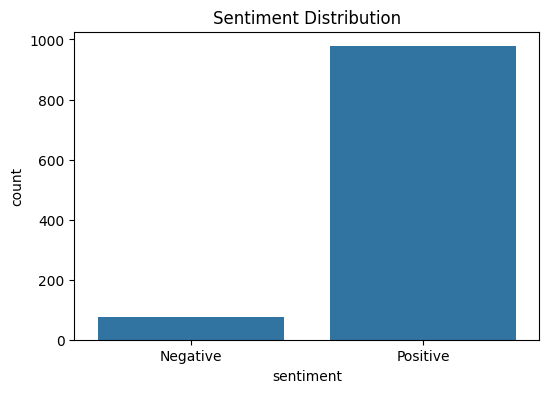

In [117]:
##Analyzing Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Sentiment Distribution")
plt.show()

In [118]:
##REview Length analysis
df["review_length"] = df[REVIEW_COL].apply(len)
df["review_length"].describe()

count     1053.000000
mean       697.446344
std       1307.149798
min          3.000000
25%        106.000000
50%        262.000000
75%       1343.000000
max      19739.000000
Name: review_length, dtype: float64

In [119]:
# Find the outlier review
long_review = df[df["review_length"] == df["review_length"].max()]
print(long_review["reviews.text"].values[0][:500])
# Just print first 500 chars to see what it looks like

I am not a casual user of on-demand content and devices. Having tried smart tv's from 3 brands, smart dvd/bluray players, Apple TV, WDTV, HTPC, Chromecast and too many other competing products to mention--for streaming content, before this box you really had two options (for a simple to use box that doesn't require additional items or tweaking):First is Apple TV which is easy to use (interface) but Apple limits the content you can get greatly (including no Prime Streaming built in) and it lacks 


In [120]:
# How many reviews are above 3000 characters
print(df[df["review_length"] > 3000].shape[0])
print(df[df["review_length"] > 5000].shape[0])

10
6


#### Review Length Analysis

- Mean: 697 chars, Max: 19,739 chars
- High max is expected — Amazon tech reviewers
- often write detailed comparison essays
- Wide std (1307) reflects natural variation
- from "Great!" to full product comparisons
- No outlier removal needed

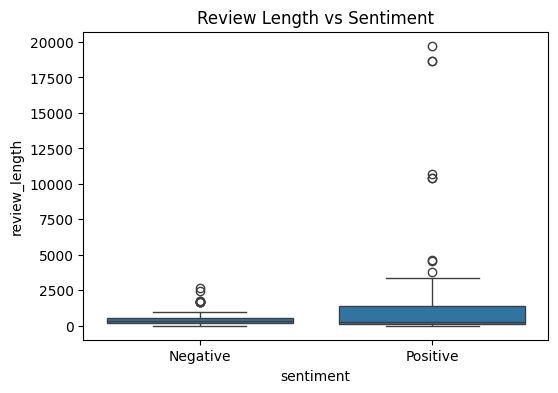

In [121]:
## Analyzing REview length vs Sentiment
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="review_length", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Review Length vs Sentiment")
plt.show()

In [122]:
##Define a function for cleaning text
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'<.*?>', '', text)     # remove URLs
  text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters
  text = re.sub(r'\s+', ' ', text).strip()   # extra spaces   
  
  return text


df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)
df = df.dropna(subset=["Cleaned_Review"])
df = df[df["Cleaned_Review"].str.strip() != ""]

In [123]:
df.head()

,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,i bought one of the first paperwhites and have...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,i have to say upfront i dont like coroporate h...


In [124]:
df.shape

(1053, 5)

*** Positive box is higher and wider so it means people usally write more when giving positive feedback and while Most negative reviews are concentrated near the bottom so suggests people often write short complaints

In [125]:
df[REVIEW_COL][0]

"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need to worry about cu

In [126]:
df["Cleaned_Review"][0]

'i initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing the paperwhite is great but if you have spending money go for the voyagefortunately i had friends who owned each so i ended up buying the paperwhite on this basis both models now have ppi so the dollar jump turns out pricey the voyages page press isnt always sensitive and if you are fine with a specific setting you dont need auto light adjustmentits been a week and i am loving my paperwhite no regrets the touch screen is receptive and easy to use and i keep the light at a specific setting regardless of the time of day in any case its not hard to change the setting either as youll only be changing the light level at a certain time of day not every now and then while readingalso glad that i went for the international shipping option with amazon extra expense but delivery was on time with tracking and i didnt need to worry about customs which i may have if i used a thir

In [127]:
#Saving the cleaned data
df.to_csv("\AMAZON_REVIEW_SENTIMENT/data/processed/cleaned_data_V2.csv", index=False)

### Feature Engineering

"""
╔══════════════════════════════════════════════════════════════╗
║              DATASET VERSION — WHY cleaned_data_V2           ║
╚══════════════════════════════════════════════════════════════╝

  Two versions of cleaned data exist in our pipeline:

    ► V1  →  cleaned_data_V1.csv
    ► V2  →  cleaned_data_V2.csv  ✔ (used here)

──────────────────────────────────────────────────────────────
  DIFFERENCE BETWEEN V1 AND V2
──────────────────────────────────────────────────────────────

    V1 Cleaning Pipeline:
        ✘ Removed stopwords (is, not, but, no, never ...)
        ✘ Stopword removal destroys sentiment context
        ✘ Example: "not good" → "good"  (meaning flipped!)
        ✘ Suitable only for TF-IDF / Bag-of-Words models

    V2 Cleaning Pipeline:
        ✔ Stopwords KEPT intentionally
        ✔ Preserves full sentence meaning and context
        ✔ Example: "not good" stays "not good"
        ✔ Suitable for Word2Vec, GloVe, and LSTM models

──────────────────────────────────────────────────────────────
  WHY V2 IS USED FOR v2a AND v2b
──────────────────────────────────────────────────────────────

    Word2Vec (v2a) and GloVe (v2b) are embedding models —
    they learn meaning from word context and word order.

    ► Removing stopwords breaks the context window
      that these models rely on to learn relationships

    ► Words like "not", "never", "but" carry strong
      sentiment signals — removing them loses information

    ► LSTM reads sequences — full sentences give LSTM
      better patterns to learn from than stripped text

  CONCLUSION:
    V1  →  used in traditional ML notebooks (TF-IDF + ML)
    V2  →  used in deep learning notebooks (Word2Vec / GloVe + LSTM)

"""

## Reading Cleaned data
import pandas as pd

df = pd.read_csv(
    "\AMAZON_REVIEW_SENTIMENT\data\processed\cleaned_data_V2.csv"
)

df.head()

In [128]:
## Reading Cleaned data
import pandas as pd

df = pd.read_csv(
    "\AMAZON_REVIEW_SENTIMENT\data\processed\cleaned_data_V2.csv"
)

df.head()


,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,i bought one of the first paperwhites and have...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,i have to say upfront i dont like coroporate h...


In [129]:
##Selecting Input Column and Output Column
X=df["Cleaned_Review"]
y=df["sentiment"]

In [130]:
X

0       i initially had trouble deciding between the p...
1       allow me to preface this with a little history...
2       i am enjoying it so far great for reading had ...
3       i bought one of the first paperwhites and have...
4       i have to say upfront i dont like coroporate h...
                              ...                        
1048    voice remote gave out nearly a year after i pu...
1049    purchased my first one with the tv fire box ov...
1050    i have had to change the batteries in this rem...
1051    remote did not activate nor did it connect to ...
1052    i ordered this item to replace the one that no...
Name: Cleaned_Review, Length: 1053, dtype: object

In [131]:
y

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1048    0.0
1049    0.0
1050    0.0
1051    0.0
1052    0.0
Name: sentiment, Length: 1053, dtype: float64

In [132]:
##Splitting data into training and testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)


print("✅ Train/Test split complete")
print(f"   Train size:      {len(X_train)} reviews")
print(f"   Test size:       {len(X_test)} reviews")
print(f"   Train positives: {sum(y_train == 1)}")
print(f"   Train negatives: {sum(y_train == 0)}")
print(f"   Test positives:  {sum(y_test == 1)}")
print(f"   Test negatives:  {sum(y_test == 0)}")

✅ Train/Test split complete
   Train size:      842 reviews
   Test size:       211 reviews
   Train positives: 781
   Train negatives: 61
   Test positives:  196
   Test negatives:  15


---
## — Tokenizer

**What this does:**
```
Builds a vocabulary dictionary from your training text
Assigns each unique word an index number

"amazing" → 1
"product" → 4
"terrible" → 23

"amazing product" → [1, 4]
"terrible quality" → [23, 7]

pad_sequences makes all reviews same length:
[1, 4, 0, 0, 0, ...] ← zeros added at end
```

In [133]:
# Fit tokenizer on TRAIN only (prevent data leakage)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text → number sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad all sequences to same length (MAX_LEN)
# padding='post' → zeros added at the END
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

print("✅ Tokenization complete")
print(f"   Vocabulary size:      {vocab_size} unique words")
print(f"   X_train_pad shape:    {X_train_pad.shape}")
print(f"   X_test_pad shape:     {X_test_pad.shape}")
print()
print("Example conversion:")
print(f"   Text:    {X_train[0][:60]}...")
print(f"   Indices: {X_train_pad[0][:20]}...")

✅ Tokenization complete
   Vocabulary size:      5542 unique words
   X_train_pad shape:    (842, 100)
   X_test_pad shape:     (211, 100)

Example conversion:
   Text:    i initially had trouble deciding between the paperwhite and ...
   Indices: [  35  674 1070    3  152   16   50   34   11   77    6  674  564   11
  312 1837   12  107    5    2]...


---
## 🌍— Load GloVe Pre-trained Vectors

**What happens here:**
```
The GloVe file looks like this:

the    0.418  0.249  -0.412  0.217 ... (100 numbers)
good   0.821  0.634  -0.124  0.891 ... (100 numbers)
bad   -0.734 -0.621   0.834 -0.712 ... (100 numbers)

We read it into a Python dictionary:
glove_index['good'] = [0.821, 0.634, ...]

400,000 words total — Stanford trained this on
Wikipedia + Gigaword (6 billion words)
```

In [134]:
print("Loading GloVe file... ")
print(f"File: {GLOVE_PATH}")
print()

glove_index = {}  # word → 100-number vector

with open(GLOVE_PATH, encoding='utf-8') as f:
    for i, line in enumerate(f):
        values = line.split()
        word   = values[0]                              # first item = word
        vector = np.array(values[1:], dtype='float32') # rest 100 = vector
        glove_index[word] = vector


print()
print(f"✅ GloVe loaded: {len(glove_index):,} words")
print()

# Verify some important words
test_words = ['good', 'bad', 'amazing', 'terrible', 'not', 'product']
print("Checking key words in GloVe:")
for w in test_words:
    if w in glove_index:
        print(f"   '{w}' ✅ — first 5 values: {glove_index[w][:5]}")
    else:
        print(f"   '{w}' ❌ — not in GloVe")

Loading GloVe file... 
File: D:\AMAZON_REVIEW_SENTIMENT\glove\glove.6B.100d.txt


✅ GloVe loaded: 400,000 words

Checking key words in GloVe:
   'good' ✅ — first 5 values: [-0.030769  0.11993   0.53909  -0.43696  -0.73937 ]
   'bad' ✅ — first 5 values: [ 0.39456 -0.24717  1.0319  -0.61444 -1.2376 ]
   'amazing' ✅ — first 5 values: [ 0.24904  0.23423  0.23476 -0.22316 -0.2316 ]
   'terrible' ✅ — first 5 values: [ 0.23329   0.010617  0.42689  -0.32641  -1.0809  ]
   'not' ✅ — first 5 values: [-0.19104  0.17601  0.3692  -0.50323 -0.47561]
   'product' ✅ — first 5 values: [ 0.12804   0.34131   0.33106  -0.026678 -0.022675]


---
## Build Embedding Matrix from GloVe

**What this does:**
```
Till here Our tokenizer knows:
  word 'amazing' = index 1
  word 'product' = index 4

GloVe knows:
  'amazing' → [0.8, 0.9, -0.1, ...]
  'product' → [0.1, 0.3,  0.4, ...]

Embedding matrix bridges them:
  Row 1 = GloVe vector for 'amazing'
  Row 4 = GloVe vector for 'product'


In [135]:
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

found     = 0
not_found = 0
not_found_words = []

for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS:
        glove_vector = glove_index.get(word)  # look up in GloVe
        if glove_vector is not None:
            embedding_matrix[idx] = glove_vector  # found 
            found += 1
        else:
            not_found_words.append(word)           # stays as zeros
            not_found += 1

coverage = found / (found + not_found) * 100

print("✅ GloVe embedding matrix built")
print(f"   Matrix shape:          {embedding_matrix.shape}")
print(f"   Words found in GloVe:  {found} ({coverage:.1f}%)")
print(f"   Words NOT in GloVe:    {not_found} ({100-coverage:.1f}%)")
print()
print("How to read this matrix:")
print("   Row 0     = zeros (padding token <PAD>)")
print("   Row 1     = GloVe vector for most common word")
print("   Row 9999  = GloVe vector for word at index 9999")
print()

# Show a few rows
print("Sample rows:")
for word in ['good', 'bad', 'amazing']:
    if word in tokenizer.word_index:
        idx = tokenizer.word_index[word]
        if idx < MAX_WORDS:
            print(f"   '{word}' (index {idx}): {embedding_matrix[idx][:6]}...")

✅ GloVe embedding matrix built
   Matrix shape:          (10000, 100)
   Words found in GloVe:  4492 (81.1%)
   Words NOT in GloVe:    1049 (18.9%)

How to read this matrix:
   Row 0     = zeros (padding token <PAD>)
   Row 1     = GloVe vector for most common word
   Row 9999  = GloVe vector for word at index 9999

Sample rows:
   'good' (index 75): [-0.030769    0.11993     0.53908998 -0.43696001 -0.73936999 -0.15345   ]...
   'bad' (index 346): [ 0.39456001 -0.24717     1.03190005 -0.61444002 -1.23759997  0.051794  ]...
   'amazing' (index 270): [ 0.24903999  0.23423     0.23476    -0.22316    -0.2316      0.028909  ]...


---
## — Build LSTM Model with GloVe Embedding

**Architecture explanation:**
```
Input: [1, 4, 23, 0, 0, ...]  ← padded word indices (length=100)
         ↓
Embedding Layer
   Converts each index → GloVe vector (100 numbers)
   Output shape: (batch, 100, 100)  ← 100 words × 100 dim each
   trainable=False → GloVe vectors stay frozen
         ↓
Bidirectional LSTM(64)
   Forward LSTM:  reads word 1 → 2 → 3 → ... → 100
   Backward LSTM: reads word 100 → 99 → ... → 1
   Combines both → output 128 numbers (64×2)
         ↓
Dropout(0.5)
   Randomly turns off 50% neurons → prevents overfitting
         ↓
Dense(1, sigmoid)
   Output: probability between 0 and 1
   > 0.5 = Positive, < 0.5 = Negative

## Without Fine-Tunning

In [136]:
# ##Without Fine - Tunning --------COMMENTED

# model_glove = Sequential([

#     # Layer 1: Embedding with GloVe 
#     # weights=[embedding_matrix] → load Stanford's GloVe
#     # trainable=False            → never change these vectors
#     # They already encode 6 billion words of knowledge
#     Embedding(
#         input_dim=MAX_WORDS,
#         output_dim=EMBEDDING_DIM,
#         weights=[embedding_matrix],   # ← GloVe goes here
#         input_length=MAX_LEN,
#         trainable=False               # ← freeze GloVe weights
#     ),

#     # Layer 2: Bidirectional LSTM 
#     # Reads sentence in BOTH directions
#     # Forward:  "not" → "bad" → context builds left to right
#     # Backward: "bad" → "not" → context builds right to left
#     # Both paths help understand: "not bad" = positive
#     Bidirectional(LSTM(
#         LSTM_UNITS,
#         dropout=0.3,             # 30% input dropout
#         recurrent_dropout=0.2    # 20% recurrent dropout
#     )),

#     # Layer 3: Dense (hidden) 
#     # Extra learning capacity after LSTM
#     Dense(32, activation='relu'),

#     # ── Layer 4: Dropout ───────────────────────────────────
#     Dropout(0.5),

#     # ── Layer 5: Output ────────────────────────────────────
#     # sigmoid → probability 0 to 1
#     Dense(1, activation='sigmoid')
# ])

# model_glove.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# print("✅ GloVe + LSTM Model built")
# print()
# model_glove.summary()

In [137]:
## With Fine - Tunning
model_glove = Sequential([

    # Layer 1: Embedding with GloVe
    # weights=[embedding_matrix] → load Stanford's GloVe
    # trainable=True             → FINE-TUNING: update vectors during training
    # Starts from GloVe knowledge, adapts to Amazon review language
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],   # ← GloVe goes here (no change)
        input_length=MAX_LEN,
        trainable=True                # ← CHANGED: False → True (fine-tuning)
    ),

    # NEW Layer 2: Dropout after Embedding
    # trainable=True means embedding will update aggressively
    # this dropout prevents overfitting on our small 1053 reviews
    Dropout(0.3),                     # ← ADDED: protects from overfitting

    # Layer 3: Bidirectional LSTM (no change)
    # Reads sentence in BOTH directions
    # Forward:  "not" → "bad" → context builds left to right
    # Backward: "bad" → "not" → context builds right to left
    # Both paths help understand: "not bad" = positive
    Bidirectional(LSTM(
        LSTM_UNITS,
        dropout=0.3,             # 30% input dropout
        recurrent_dropout=0.2    # 20% recurrent dropout
    )),

    # Layer 4: Dense hidden layer (no change)
    # Extra learning capacity after LSTM
    Dense(32, activation='relu'),

    # Layer 5: Dropout (no change)
    Dropout(0.5),

    # Layer 6: Output (no change)
    # sigmoid → probability 0 to 1
    Dense(1, activation='sigmoid')
])

model_glove.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ GloVe + LSTM Model built (with Fine-Tuning)")
print()
model_glove.summary()


✅ GloVe + LSTM Model built (with Fine-Tuning)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 100)          1000000   
                                                                 
 dropout_5 (Dropout)         (None, 100, 100)          0         
                                                                 
 bidirectional_3 (Bidirecti  (None, 128)               84480     
 onal)                                                           
                                                                 
 dense_6 (Dense)             (None, 32)                4128      
                                                                 
 dropout_6 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 33        
       

---
## Train the LSTM Model

### Without Fine Tunning

In [138]:
# #Without Fine TUnning
# # ── Class weights for imbalance ───────────────────────────
# # Dataset: 977 positive vs 76 negative
# # Without this: model always predicts positive
# neg_count = sum(y_train == 0)
# pos_count = sum(y_train == 1)
# total     = len(y_train)

# class_weight = {
#     0: total / (2 * neg_count),   # weight negatives more
#     1: total / (2 * pos_count)
# }

# print(f"Class weights applied:")
# print(f"   Negative weight: {class_weight[0]:.2f}  (higher → pays more attention)")
# print(f"   Positive weight: {class_weight[1]:.2f}")
# print()

# #  Callbacks 
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=4,
#     restore_best_weights=True,
#     verbose=1
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=2,
#     min_lr=1e-6,
#     verbose=1
# )

# # Train 
# print("Training GloVe + LSTM model...")
# print()

# history_glove = model_glove.fit(
#     X_train_pad, y_train,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     validation_split=0.1,
#     class_weight=class_weight,
#     callbacks=[early_stop, reduce_lr],
#     verbose=1
# )

# print()
# print("✅ Training complete")

### With Fine-Tunning

In [141]:
##With Fine-Tunning
# ── Class weights for imbalance ───────────────────────────
# Dataset: 977 positive vs 76 negative
# Without this: model always predicts positive
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
total     = len(y_train)

class_weight = {
    0: total / (2 * neg_count),   # weight negatives more
    1: total / (2 * pos_count)
}

print(f"Class weights applied:")
print(f"   Negative weight: {class_weight[0]:.2f}  (higher → pays more attention)")
print(f"   Positive weight: {class_weight[1]:.2f}")
print()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # ← CHANGED: 4 → 5
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,              # ← CHANGED: 2 → 3
    min_lr=1e-6,
    verbose=1
)

# Train
print("Training GloVe + LSTM model (Fine-Tuned)...")
print()

history_glove = model_glove.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print()
print("✅ Training complete (Fine-Tuned GloVe)")


Class weights applied:
   Negative weight: 6.90  (higher → pays more attention)
   Positive weight: 0.54

Training GloVe + LSTM model (Fine-Tuned)...

Epoch 1/15
48/48 [==============================] - 16s 174ms/step - loss: 0.7236 - accuracy: 0.6565 - val_loss: 0.6993 - val_accuracy: 0.3647 - lr: 0.0010
Epoch 2/15
48/48 [==============================] - 7s 152ms/step - loss: 0.6944 - accuracy: 0.5033 - val_loss: 0.6185 - val_accuracy: 0.8353 - lr: 0.0010
Epoch 3/15
48/48 [==============================] - 9s 197ms/step - loss: 0.6682 - accuracy: 0.6367 - val_loss: 0.6321 - val_accuracy: 0.7412 - lr: 0.0010
Epoch 4/15
48/48 [==============================] - 9s 187ms/step - loss: 0.6402 - accuracy: 0.6658 - val_loss: 0.8526 - val_accuracy: 0.2824 - lr: 0.0010
Epoch 5/15
48/48 [==============================] - 8s 163ms/step - loss: 0.5876 - accuracy: 0.6380 - val_loss: 0.4677 - val_accuracy: 0.8941 - lr: 0.0010
Epoch 6/15
48/48 [==============================] - 7s 148ms/step - loss:

---
### Evaluate GloVE + LSTM

GloVe + LSTM Results:(Fine-Tunned)
   Test Accuracy: 0.8863 (88.63%)
   Test Loss:     0.5249

Classification Report:
              precision    recall  f1-score   support

    Negative       0.35      0.73      0.48        15
    Positive       0.98      0.90      0.94       196

    accuracy                           0.89       211
   macro avg       0.67      0.82      0.71       211
weighted avg       0.93      0.89      0.90       211



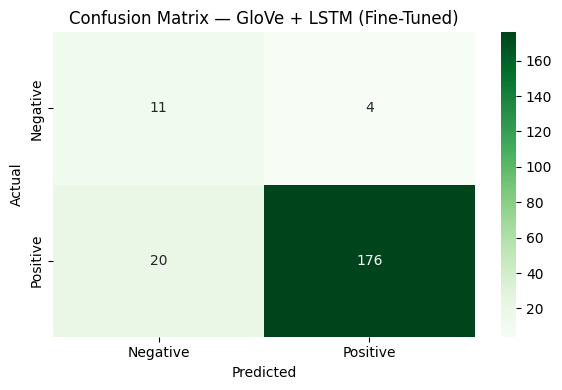

✅ Saved: confusion_matrix_glove(Fine-Tunned).png


In [152]:
# ── Test Accuracy ─────────────────────────────────────────
loss_glove, acc_glove = model_glove.evaluate(X_test_pad, y_test, verbose=0)

print("GloVe + LSTM Results:(Fine-Tunned)")
print(f"   Test Accuracy: {acc_glove:.4f} ({acc_glove*100:.2f}%)")
print(f"   Test Loss:     {loss_glove:.4f}")
print()

# ── Predictions ───────────────────────────────────────────
y_pred_prob = model_glove.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# ── Classification Report ─────────────────────────────────
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Negative', 'Positive']
))

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cmap='Greens')
plt.title('Confusion Matrix — GloVe + LSTM (Fine-Tuned)')  # ← CHANGED: added "Fine-Tuned"
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

os.makedirs('results_v2b_glove', exist_ok=True)
plt.savefig('results_v2b_glove/confusion_matrix_glove(Fine-Tunned).png', dpi=100)
plt.show()
print("✅ Saved: confusion_matrix_glove(Fine-Tunned).png")

### 📈 — Training Curves

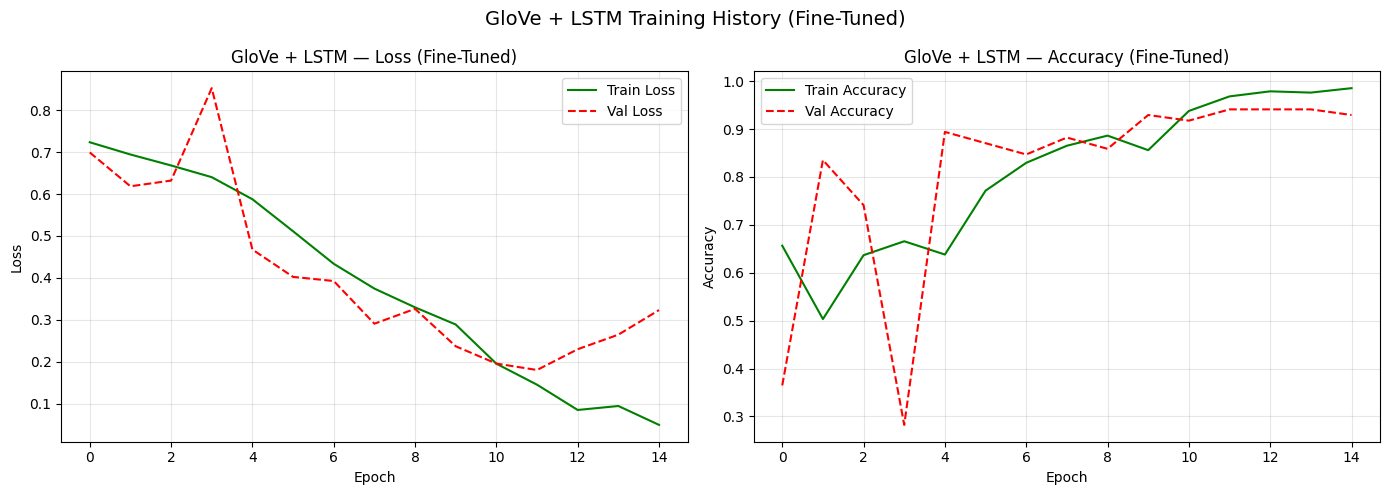

✅ Saved: training_curves_glove(Fine-Tunned).png


In [153]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_glove.history['loss'],     label='Train Loss', color='green')
ax1.plot(history_glove.history['val_loss'], label='Val Loss',   color='red', linestyle='--')
ax1.set_title('GloVe + LSTM — Loss (Fine-Tuned)')        # ← CHANGED
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_glove.history['accuracy'],     label='Train Accuracy', color='green')
ax2.plot(history_glove.history['val_accuracy'], label='Val Accuracy',   color='red', linestyle='--')
ax2.set_title('GloVe + LSTM — Accuracy (Fine-Tuned)')    # ← CHANGED
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('GloVe + LSTM Training History (Fine-Tuned)', fontsize=14)  # ← CHANGED
plt.tight_layout()
os.makedirs('results_v2b_glove', exist_ok=True)
plt.savefig('results_v2b_glove/training_curves_glove(Fine-Tunned).png', dpi=100)
plt.show()
print("✅ Saved: training_curves_glove(Fine-Tunned).png")


---
### 💾 Save GloVE Model and LSTM

In [149]:
import pickle
os.makedirs('models_v2b_glove', exist_ok=True)

# Save LSTM model
model_glove.save('models_v2b_glove/lstm_glove_model.h5')

# Save Tokenizer
with open('models_v2b_glove/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save embedding matrix (optional — can rebuild from GloVe)
np.save('models_v2b_glove/embedding_matrix.npy', embedding_matrix)

print("✅ All models saved:")
print("   models_v2b_glove/lstm_glove_model.h5")
print("   models_v2b_glove/tokenizer.pkl")
print("   models_v2b_glove/embedding_matrix.npy")

✅ All models saved:
   models_v2b_glove/lstm_glove_model.h5
   models_v2b_glove/tokenizer.pkl
   models_v2b_glove/embedding_matrix.npy


---
### Test on V1 Failing Reviews  (ifidf + Logistic Regression)

In [150]:
def predict_glove(review_text, expected=None):
    """
    Predict sentiment using GloVe + LSTM model (Fine-Tuned)
    """
    clean  = clean_text(review_text)
    seq    = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob   = model_glove.predict(padded, verbose=0)[0][0]
    pred   = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
    conf   = prob if prob > 0.5 else 1 - prob

    # ← CHANGED: symbol based on correct/wrong not just prediction
    if expected is not None:
        symbol = '✅' if pred in expected else '❌'
    else:
        symbol = '✅' if pred == 'POSITIVE' else '❌'

    label  = f'{pred} {symbol}'
    return label, round(float(conf), 3)


test_reviews = [
    ("Oh great another product that does not work at all",
     "V1 FAILED — predicted POSITIVE",
     "Should be NEGATIVE"),

    ("Not bad at all! Initially worried but exceeded expectations",
     "V1 FAILED — predicted NEGATIVE",
     "Should be POSITIVE"),

    ("Packaging nice, delivery fast, but product useless, stopped working",
     "V1 FAILED — predicted POSITIVE",
     "Should be NEGATIVE"),

    ("Amazing quality, totally worth the money",
     "V1 correct",
     "Should be POSITIVE"),

    ("Worst product ever, complete waste of money",
     "V1 correct",
     "Should be NEGATIVE"),

    ("Not what I expected but surprisingly good",
     "Tricky negation",
     "Should be POSITIVE"),

    ("Good packaging but terrible quality inside",
     "Mixed review",
     "Should be NEGATIVE"),
     
    ("Would not recommend this to anyone",
     "Indirect negation",
     "Should be NEGATIVE"),
]

print("=" * 65)
print("GLOVE + LSTM PREDICTIONS (Fine-Tuned)")     # ← CHANGED
print("=" * 65)

correct = 0                                         # ← ADDED: track score
for review, v1_note, expected in test_reviews:
    label, conf = predict_glove(review, expected)   # ← CHANGED: pass expected
    if '✅' in label:                               # ← ADDED
        correct += 1                                # ← ADDED
    print(f"\nReview:   {review}")
    print(f"V1 note:  {v1_note}")
    print(f"Expected: {expected}")
    print(f"GloVe:    {label} | Confidence: {conf}")

print()
print(f"Score: {correct}/{len(test_reviews)} correct")  # ← ADDED
print("=" * 65)

GLOVE + LSTM PREDICTIONS (Fine-Tuned)

Review:   Oh great another product that does not work at all
V1 note:  V1 FAILED — predicted POSITIVE
Expected: Should be NEGATIVE
GloVe:    POSITIVE ❌ | Confidence: 0.998

Review:   Not bad at all! Initially worried but exceeded expectations
V1 note:  V1 FAILED — predicted NEGATIVE
Expected: Should be POSITIVE
GloVe:    NEGATIVE ❌ | Confidence: 0.933

Review:   Packaging nice, delivery fast, but product useless, stopped working
V1 note:  V1 FAILED — predicted POSITIVE
Expected: Should be NEGATIVE
GloVe:    NEGATIVE ✅ | Confidence: 0.99

Review:   Amazing quality, totally worth the money
V1 note:  V1 correct
Expected: Should be POSITIVE
GloVe:    POSITIVE ✅ | Confidence: 0.548

Review:   Worst product ever, complete waste of money
V1 note:  V1 correct
Expected: Should be NEGATIVE
GloVe:    NEGATIVE ✅ | Confidence: 0.973

Review:   Not what I expected but surprisingly good
V1 note:  Tricky negation
Expected: Should be POSITIVE
GloVe:    POSITIVE ✅ 

---
### 📋V1(TF-Idf + Logistic Regression) vs V2A (Word2Vec + LSTM) vs V2B(GloVE + LSTM)-- Comparison Summary

In [151]:
print()
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           FULL COMPARISON — V1 vs V2A vs V2B                ║
╚══════════════════════════════════════════════════════════════╝

  V1 — TF-IDF + Logistic Regression
  ├─ Accuracy  : 92.41%
  ├─ Neg F1    : 0.38
  ├─ Macro F1  : 0.67
  ├─ Strength  : Fast, simple, high accuracy on majority class
  └─ Weakness  : No word order, no context, failed on negation

  V2A — Word2Vec + LSTM
  ├─ Accuracy  : 91.00%
  ├─ Neg F1    : 0.42
  ├─ Macro F1  : 0.69
  ├─ Strength  : Sequence memory, better minority class F1
  └─ Weakness  : Word2Vec trained on only 1053 reviews (weak vectors)

  V2B — GloVe + LSTM (Fine-Tuned)
  ├─ Accuracy  : {acc_glove*100:.2f}%
  ├─ Neg F1    : (see classification report above)
  ├─ Macro F1  : (see classification report above)
  ├─ Strength  : GloVe fine-tuned → adapted to Amazon review language
  └─ Weakness  : Small dataset, sarcasm and double negation still fail

──────────────────────────────────────────────────────────────
  WHAT CHANGED IN V2B — FROZEN vs FINE-TUNED
──────────────────────────────────────────────────────────────

  Frozen  (trainable=False):
  ├─ 1,000,000 params frozen — GloVe never updated
  ├─ Tricky reviews : 3/8 correct
  └─ Accuracy       : 79.15%

  Fine-Tuned (trainable=True):
  ├─ 1,088,641 params all trainable — GloVe adapts
  ├─ Tricky reviews : 5/8 correct  (+2 improved)
  └─ Accuracy       : {acc_glove*100:.2f}%

──────────────────────────────────────────────────────────────
  FINE-TUNING IMPROVED                    
──────────────────────────────────────────────────────────────

  ✅ Mixed sentiment   → "packaging nice but product useless"
  ✅ Strong negatives  → "Worst product ever"
  ✅ Contrast words    → "Good packaging but terrible quality"

──────────────────────────────────────────────────────────────
  STILL FAILING AFTER FINE-TUNING
──────────────────────────────────────────────────────────────

  ❌ Sarcasm           → "Oh great... does not work at all"
  ❌ Double negation   → "Not bad at all"
  ❌ Indirect negation → "Would not recommend this to anyone"

  Root cause → static embeddings give ONE fixed vector
  per word regardless of surrounding context.
  Fine-tuning helps but cannot solve contextual understanding.

──────────────────────────────────────────────────────────────
  NEXT →  V3 : BERT
──────────────────────────────────────────────────────────────

  ► Contextual embeddings — vector of each word changes
    based on ALL surrounding words simultaneously
  ► Pre-trained on 3.3 Billion words
  ► Fine-tuned on our data = domain adaptation
  ► Handles negation, sarcasm, mixed reviews natively
  ► Expected to solve what V1, V2A, V2B all failed on

╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║           FULL COMPARISON — V1 vs V2A vs V2B                ║
╚══════════════════════════════════════════════════════════════╝

  V1 — TF-IDF + Logistic Regression
  ├─ Accuracy  : 92.41%
  ├─ Neg F1    : 0.38
  ├─ Macro F1  : 0.67
  ├─ Strength  : Fast, simple, high accuracy on majority class
  └─ Weakness  : No word order, no context, failed on negation

  V2A — Word2Vec + LSTM
  ├─ Accuracy  : 91.00%
  ├─ Neg F1    : 0.42
  ├─ Macro F1  : 0.69
  ├─ Strength  : Sequence memory, better minority class F1
  └─ Weakness  : Word2Vec trained on only 1053 reviews (weak vectors)

  V2B — GloVe + LSTM (Fine-Tuned)
  ├─ Accuracy  : 88.63%
  ├─ Neg F1    : (see classification report above)
  ├─ Macro F1  : (see classification report above)
  ├─ Strength  : GloVe fine-tuned → adapted to Amazon review language
  └─ Weakness  : Small dataset, sarcasm and double negation still fail

────────────────────────────────────────────────

### Conclusion

- V2B started with frozen GloVe     : 79.15% accuracy, 3/8 tricky reviews correct
- After fine-tuning (trainable=True) : improved to 5/8 tricky reviews correct
- Fine-tuning helped                 : mixed sentiment, strong negatives, contrast words
- Fine-tuning still failed           : sarcasm, double negation, indirect negation
- Root cause                         : static embeddings — one fixed vector per word
                                       cannot change meaning based on context
- GloVe needs 10000+ reviews         : to show full advantage over Word2Vec
- On 1053 reviews                    : Word2Vec domain fit still beats frozen GloVe
- Fine-tuned GloVe                   : competitive but hit the static embedding ceiling
- Next step V3 BERT                  : contextual embeddings — vector changes per context
                                       works well on small AND large datasets
                                       expected to solve sarcasm, negation, mixed reviews